In [1]:
# forçando o repositorio a encontrar src
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:

import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from utils.analytics.Plot3d import Plot3d
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.x13 import x13_arima_analysis


In [3]:
data_path = os.path.join('..','data', 'raw', 'dados_completos.csv')
df = pd.read_csv(data_path)
df

,data,4393,21084,24369,27640,4390,24364
0,2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
1,2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2,2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
3,2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
4,2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...,...
168,2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078
169,2026-04-01,121.06,5.51,5.8,2.37,1.09,110.95732
170,2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587
171,2026-06-01,124.07,NaN,NaN,NaN,1.12,NaN


4393	Índice de Confiança do Consumidor 

21084	Inadimplência da carteira de crédito - Pessoas físicas - Total 

24369	Taxa de desocupação - PNADC 

27640 - 27640	Taxa média mensal de juros das operações de crédito não rotativo - Pessoas físicas - Total 

4390 - selic 


24364	Índice de Atividade Econômica do Banco Central (IBC-Br) - com ajuste sazonal



In [4]:
df = df.rename(columns={'4393': 'Confiança_consumidor', 
                        '21084':'Inadimplencia_PF', 
                        '24369':'Desemprego',
                        '27640':'Juros_nao_rotativos_PF',
                        '4390':'SELIC', 
                        '24364':'IBC-Br'})
df

,data,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br
0,2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
1,2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2,2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
3,2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
4,2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...,...
168,2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078
169,2026-04-01,121.06,5.51,5.8,2.37,1.09,110.95732
170,2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587
171,2026-06-01,124.07,NaN,NaN,NaN,1.12,NaN


In [5]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   data                    173 non-null    datetime64[us]
 1   Confiança_consumidor    173 non-null    float64       
 2   Inadimplencia_PF        171 non-null    float64       
 3   Desemprego              171 non-null    float64       
 4   Juros_nao_rotativos_PF  171 non-null    float64       
 5   SELIC                   173 non-null    float64       
 6   IBC-Br                  171 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 9.6 KB


In [6]:
df = df.set_index('data')
df

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br
data,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...
2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078
2026-04-01,121.06,5.51,5.8,2.37,1.09,110.95732
2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Confiança_consumidor,173.0,118.075665,17.985873,84.55000,106.860000,114.23000,127.05000,165.85000
Inadimplencia_PF,171.0,4.007135,0.639783,2.89000,3.615000,3.93000,4.24500,5.62000
Desemprego,171.0,9.619883,2.824902,5.10000,7.100000,8.80000,12.10000,14.90000
Juros_nao_rotativos_PF,171.0,1.866550,0.206561,1.43000,1.720000,1.84000,2.01000,2.37000
SELIC,173.0,0.778671,0.298048,0.13000,0.540000,0.82000,1.04000,1.28000
IBC-Br,171.0,99.803206,5.169938,83.03874,96.224275,99.51646,102.85532,111.03587


In [8]:
df.isnull().sum()

Confiança_consumidor      0
Inadimplencia_PF          2
Desemprego                2
Juros_nao_rotativos_PF    2
SELIC                     0
IBC-Br                    2
dtype: int64

In [9]:
df = df.dropna()
df

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br
data,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...
2026-01-01,127.39,5.38,5.4,2.33,1.16,110.05486
2026-02-01,127.39,5.56,5.8,2.30,1.00,110.65892
2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078


C:\Users\souza\AppData\Local\Temp\ipykernel_13372\3330039567.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


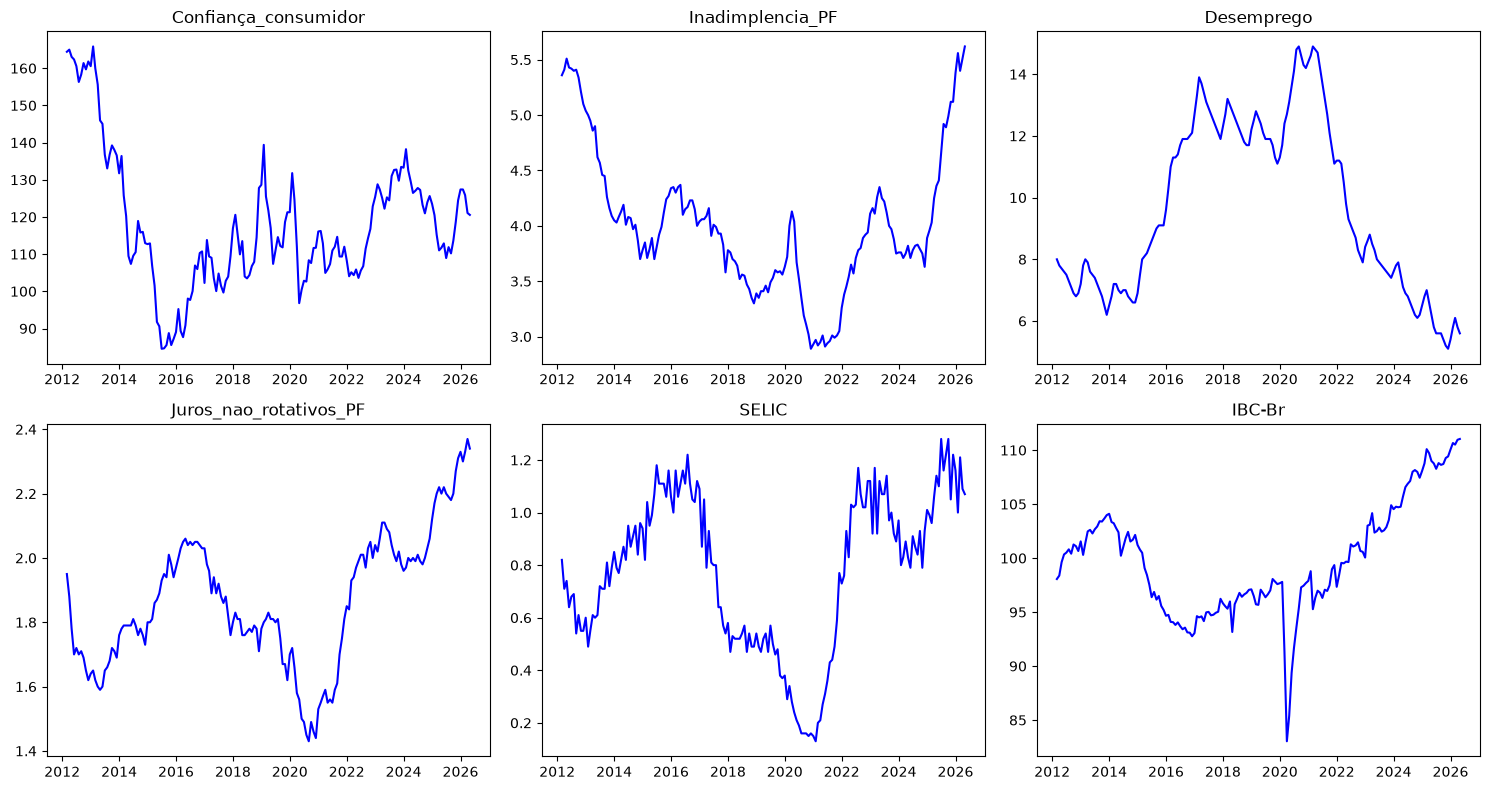

In [10]:
# plotando series agrupadas
fig, ax = plt.subplots(2, 3, figsize=(15,8))
for num, axes in zip(df.columns, ax.ravel()):
    axes.plot(df[num], color='blue')
    axes.set_title(f'{num}')
    fig.tight_layout()
    fig.show()


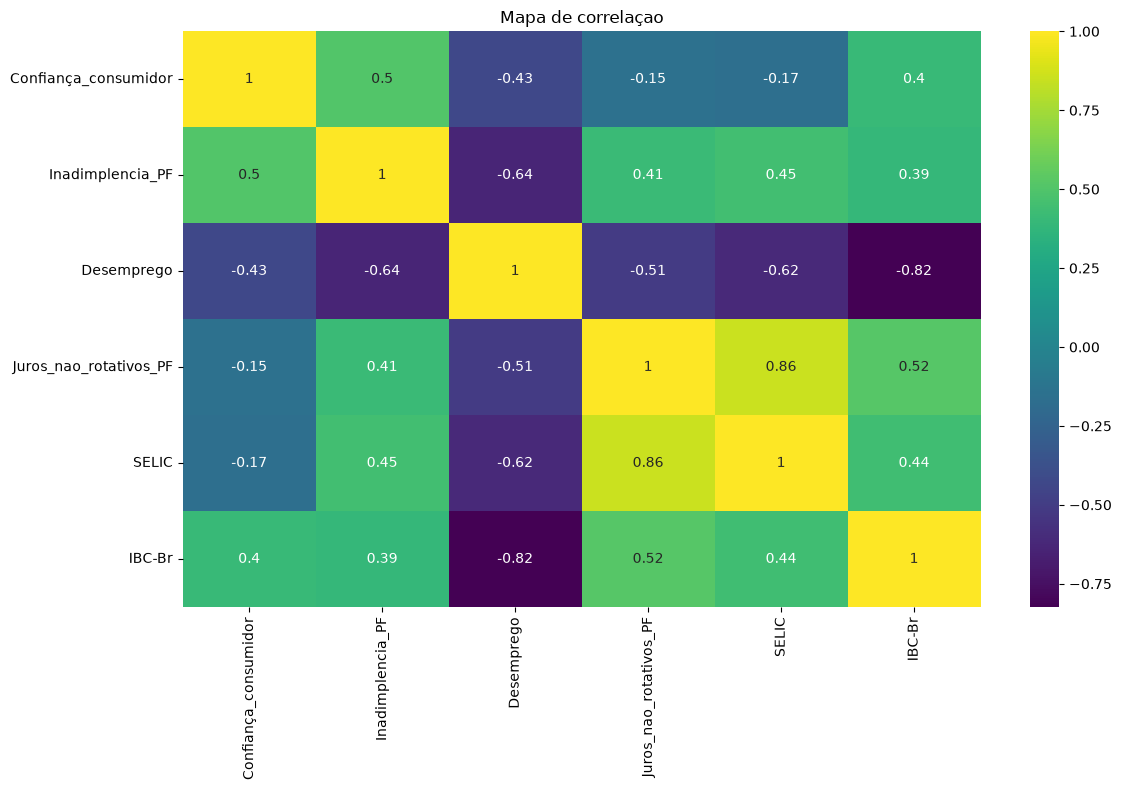

In [11]:
# calculando e plotando correlaçoes
corr = df.corr()
plt.figure(figsize=(12,8))
plt.title('Mapa de correlaçao')
sns.heatmap(corr, annot=True, cmap='viridis')
plt.tight_layout()
plt.show()


In [12]:
df.columns

Index(['Confiança_consumidor', 'Inadimplencia_PF', 'Desemprego',
       'Juros_nao_rotativos_PF', 'SELIC', 'IBC-Br'],
      dtype='str')

C:\Users\souza\AppData\Local\Temp\ipykernel_13372\2955805936.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


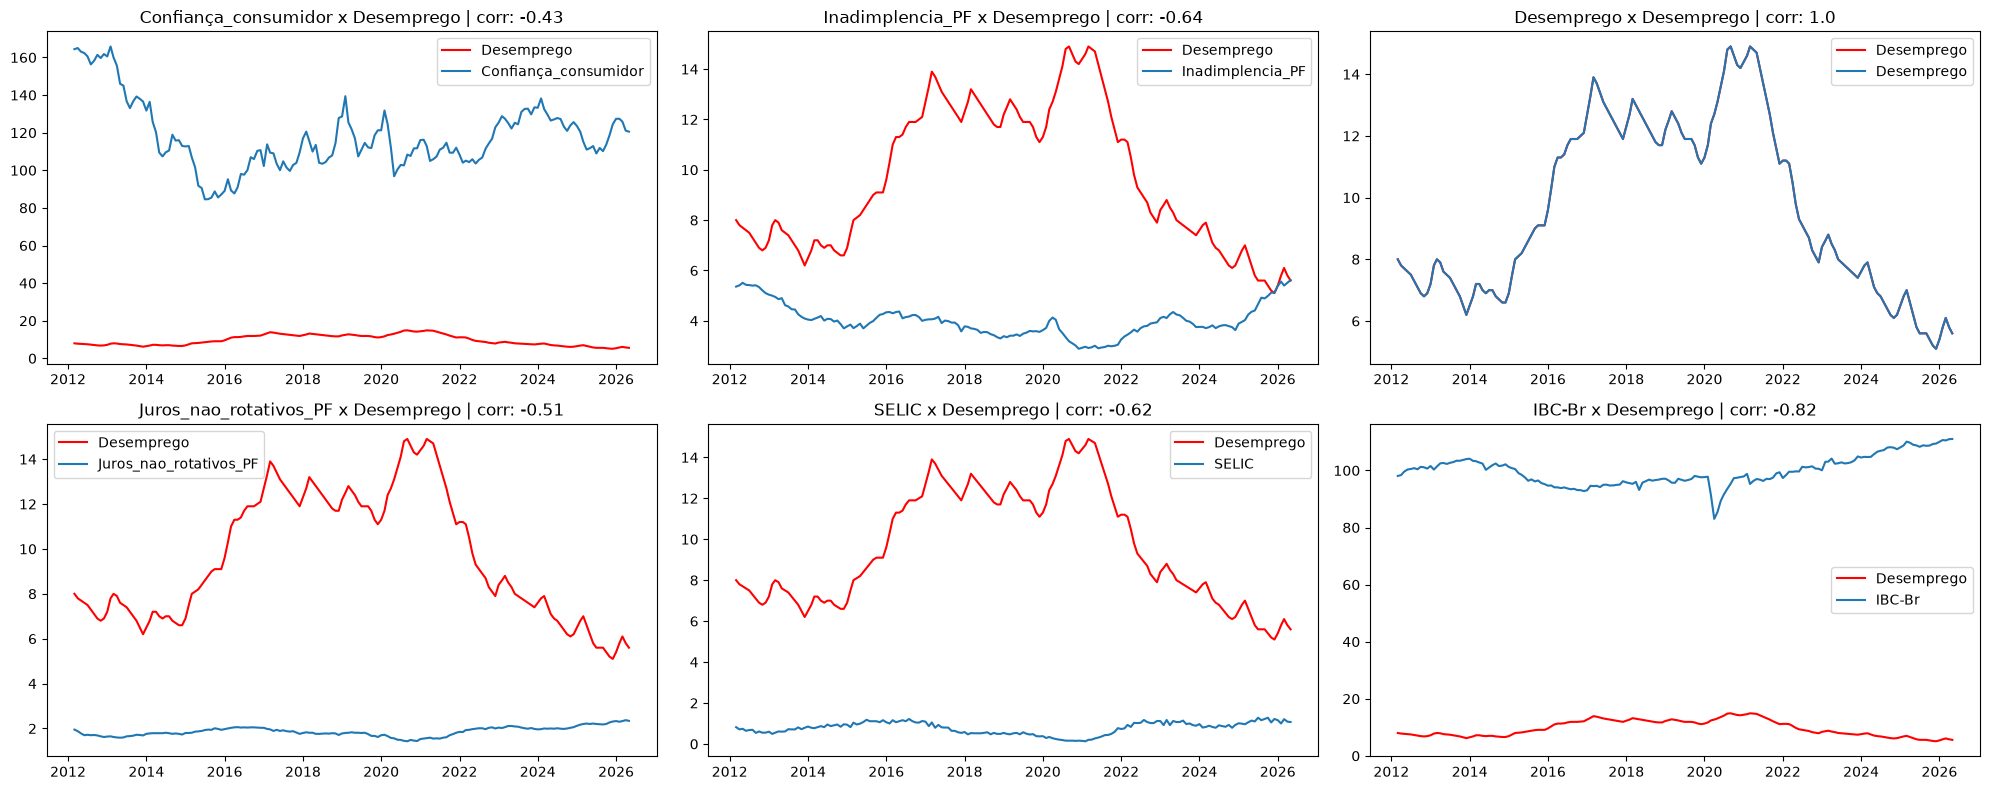

In [13]:
# relacionando taxas com o desemprego 
desemprego = df['Desemprego']
corr_desemprego = df.corr()['Desemprego']
fig, ax = plt.subplots(2, 3, figsize=(20,8))
for i, axes, corr in zip(df.columns, ax.ravel(), corr_desemprego):
    axes.plot(desemprego, color='red', label='Desemprego')
    axes.plot(df[i],label=f'{i}')
    axes.set_title(f'{i} x Desemprego | corr: {round(corr, 2)}')
    fig.tight_layout()
    axes.legend()
    fig.show()

In [14]:
fig = Plot3d(df['Desemprego'], y=df['SELIC'], z=df['Inadimplencia_PF'], title='Area de inadimplencia gerada por Desemprego e Selic')
fig.plot_surface()

-- Conseguimos enxergar clara evidencia de geraçao de area. O desemprego cai -> selic controla -> menos inadimplencia.

**NAO é causal, mas podemos enxergar boa relaçao entre essas caracteristicas** 

Nesse caso, a SELIC não é a vilã da historia, mas sim o amortecedor dessas relaçoes. 

Mesmo em alguns pontos mostrando relaçoes bem defidas, tambem vemos bastante disperçao no grafico ao lado, mostrando que não é um problema linear simples. 


In [15]:
fig_ibc = Plot3d(df['IBC-Br'], y=df['SELIC'], z=df['Inadimplencia_PF'], title='Area de inadimplencia gerada por IBC-Br e Selic')
fig_ibc.plot_surface()

essa nova Área gerada pelo IBC-br parece mais concentrada, mesmo nao afirmando relaçao monotonica. 

In [16]:
fig_desemprego = Plot3d(df['IBC-Br'], y=df['SELIC'], z=df['Desemprego'], title='Area de desemprego gerada por IBC-Br e Selic')
fig_desemprego.plot_surface()

As 3 variaveis apresentam comportamento quase linear ao olhar. O IBC-Br funciona como termometro e a selic como amortecedor. quando o ibc cai, a selic acompanha para segurar o desemprego. 

Relacionando com o grafico passado, onde o desemprego teve relações parecidas com a inadimplencia, isso mostra uma possivel existencia de relaçao 4d entre elas

**Reforçando que as analises nao confirmam causalidade economica**

In [17]:
# teste de estacionaridade 
for fuller_test in df.columns:
    p_value = adfuller(df[fuller_test], regression='c')[1]
    print(f'coluna: {fuller_test}')
    if p_value >0.05:
        print("a serie não é estacionaria")
    print()
    

coluna: Confiança_consumidor

coluna: Inadimplencia_PF
a serie não é estacionaria

coluna: Desemprego
a serie não é estacionaria

coluna: Juros_nao_rotativos_PF
a serie não é estacionaria

coluna: SELIC
a serie não é estacionaria

coluna: IBC-Br
a serie não é estacionaria



C:\Users\souza\AppData\Local\Temp\ipykernel_13372\2978837369.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


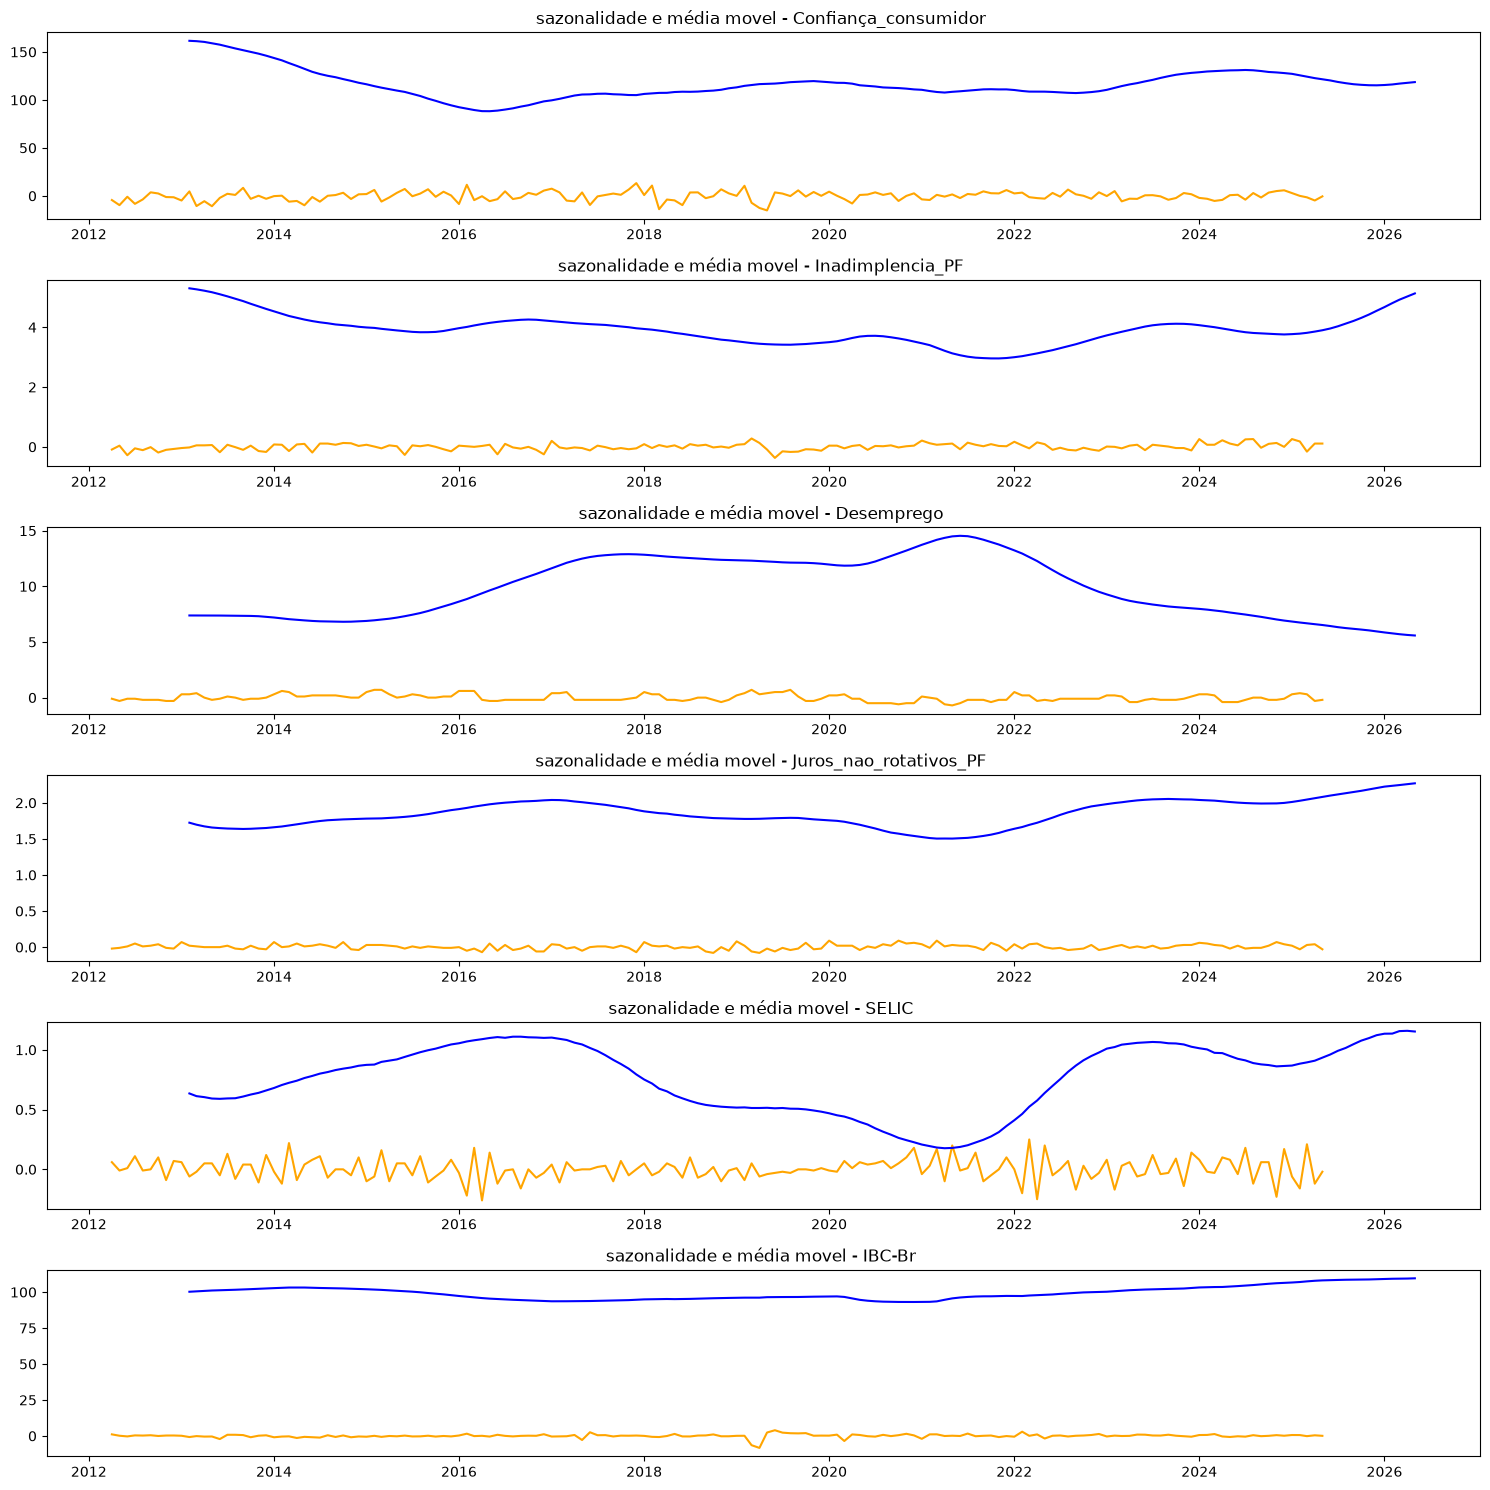

In [18]:
# sazonalidade e media movel 
fig, axes = plt.subplots(df.shape[1], 1, figsize=(15, 15))
for sazo, ax in zip(df.columns, axes.ravel()):
    sazo_ = df[sazo].shift(-12).diff()
    mavg = df[sazo].rolling(12).mean()
    ax.plot(sazo_, color='orange', label='Sazonalidade')
    ax.plot(mavg, color='blue', label='Média movel')
    ax.set_title(f'sazonalidade e média movel - {sazo} ')
    fig.tight_layout()
    fig.show()


In [19]:
# verificando multicolinearidade
X = df.drop('Inadimplencia_PF', axis=1)
X = sm.add_constant(X)
vif_df = pd.DataFrame()
vif_df['features'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df

,features,VIF
0,const,2099.329845
1,Confiança_consumidor,1.965657
2,Desemprego,7.082747
3,Juros_nao_rotativos_PF,5.477371
4,SELIC,7.577453
5,IBC-Br,4.638012


In [20]:
# separando em treino e teste para rodar no MQO
X_train = df.loc['2012-03-01':'2026-01-01']
y = df['Inadimplencia_PF']
y_train = y.loc['2012-03-01':'2026-01-01']

In [21]:
X_train

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br
data,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...
2025-09-01,110.20,4.89,5.6,2.18,1.22,108.63642
2025-10-01,113.63,4.99,5.4,2.20,1.28,108.71590
2025-11-01,118.65,5.12,5.2,2.27,1.05,109.27405


In [22]:
y_train

data
2012-03-01    5.36
2012-04-01    5.41
2012-05-01    5.51
2012-06-01    5.43
2012-07-01    5.42
              ... 
2025-09-01    4.89
2025-10-01    4.99
2025-11-01    5.12
2025-12-01    5.12
2026-01-01    5.38
Name: Inadimplencia_PF, Length: 167, dtype: float64

In [23]:
#y_train = y_train.reset_index(drop=True)
#y_train

In [24]:
y_train

data
2012-03-01    5.36
2012-04-01    5.41
2012-05-01    5.51
2012-06-01    5.43
2012-07-01    5.42
              ... 
2025-09-01    4.89
2025-10-01    4.99
2025-11-01    5.12
2025-12-01    5.12
2026-01-01    5.38
Name: Inadimplencia_PF, Length: 167, dtype: float64

In [25]:
""""
# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem 
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train= X_train.drop(['data', 'Inadimplencia_PF'], axis=1)
X_train.insert(0, 'intercepto',1)
X_train.to_csv(path_modelagem, sep=',', index=False)
"""


'"\n# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem \nX_train = X_train.reset_index()\npath_modelagem = os.path.join(\'..\', \'modeling\', \'scripts\', \'output\', \'data_modelagem.txt\')\npath_vetor_y = os.path.join(\'..\',\'modeling\', \'scripts\', \'output\', \'vetor_resposta.txt\')\nvetor_resposta = y_train\nvetor_resposta.to_csv(path_vetor_y, sep=\',\', index=False)\nX_train= X_train.drop([\'data\', \'Inadimplencia_PF\'], axis=1)\nX_train.insert(0, \'intercepto\',1)\nX_train.to_csv(path_modelagem, sep=\',\', index=False)\n'

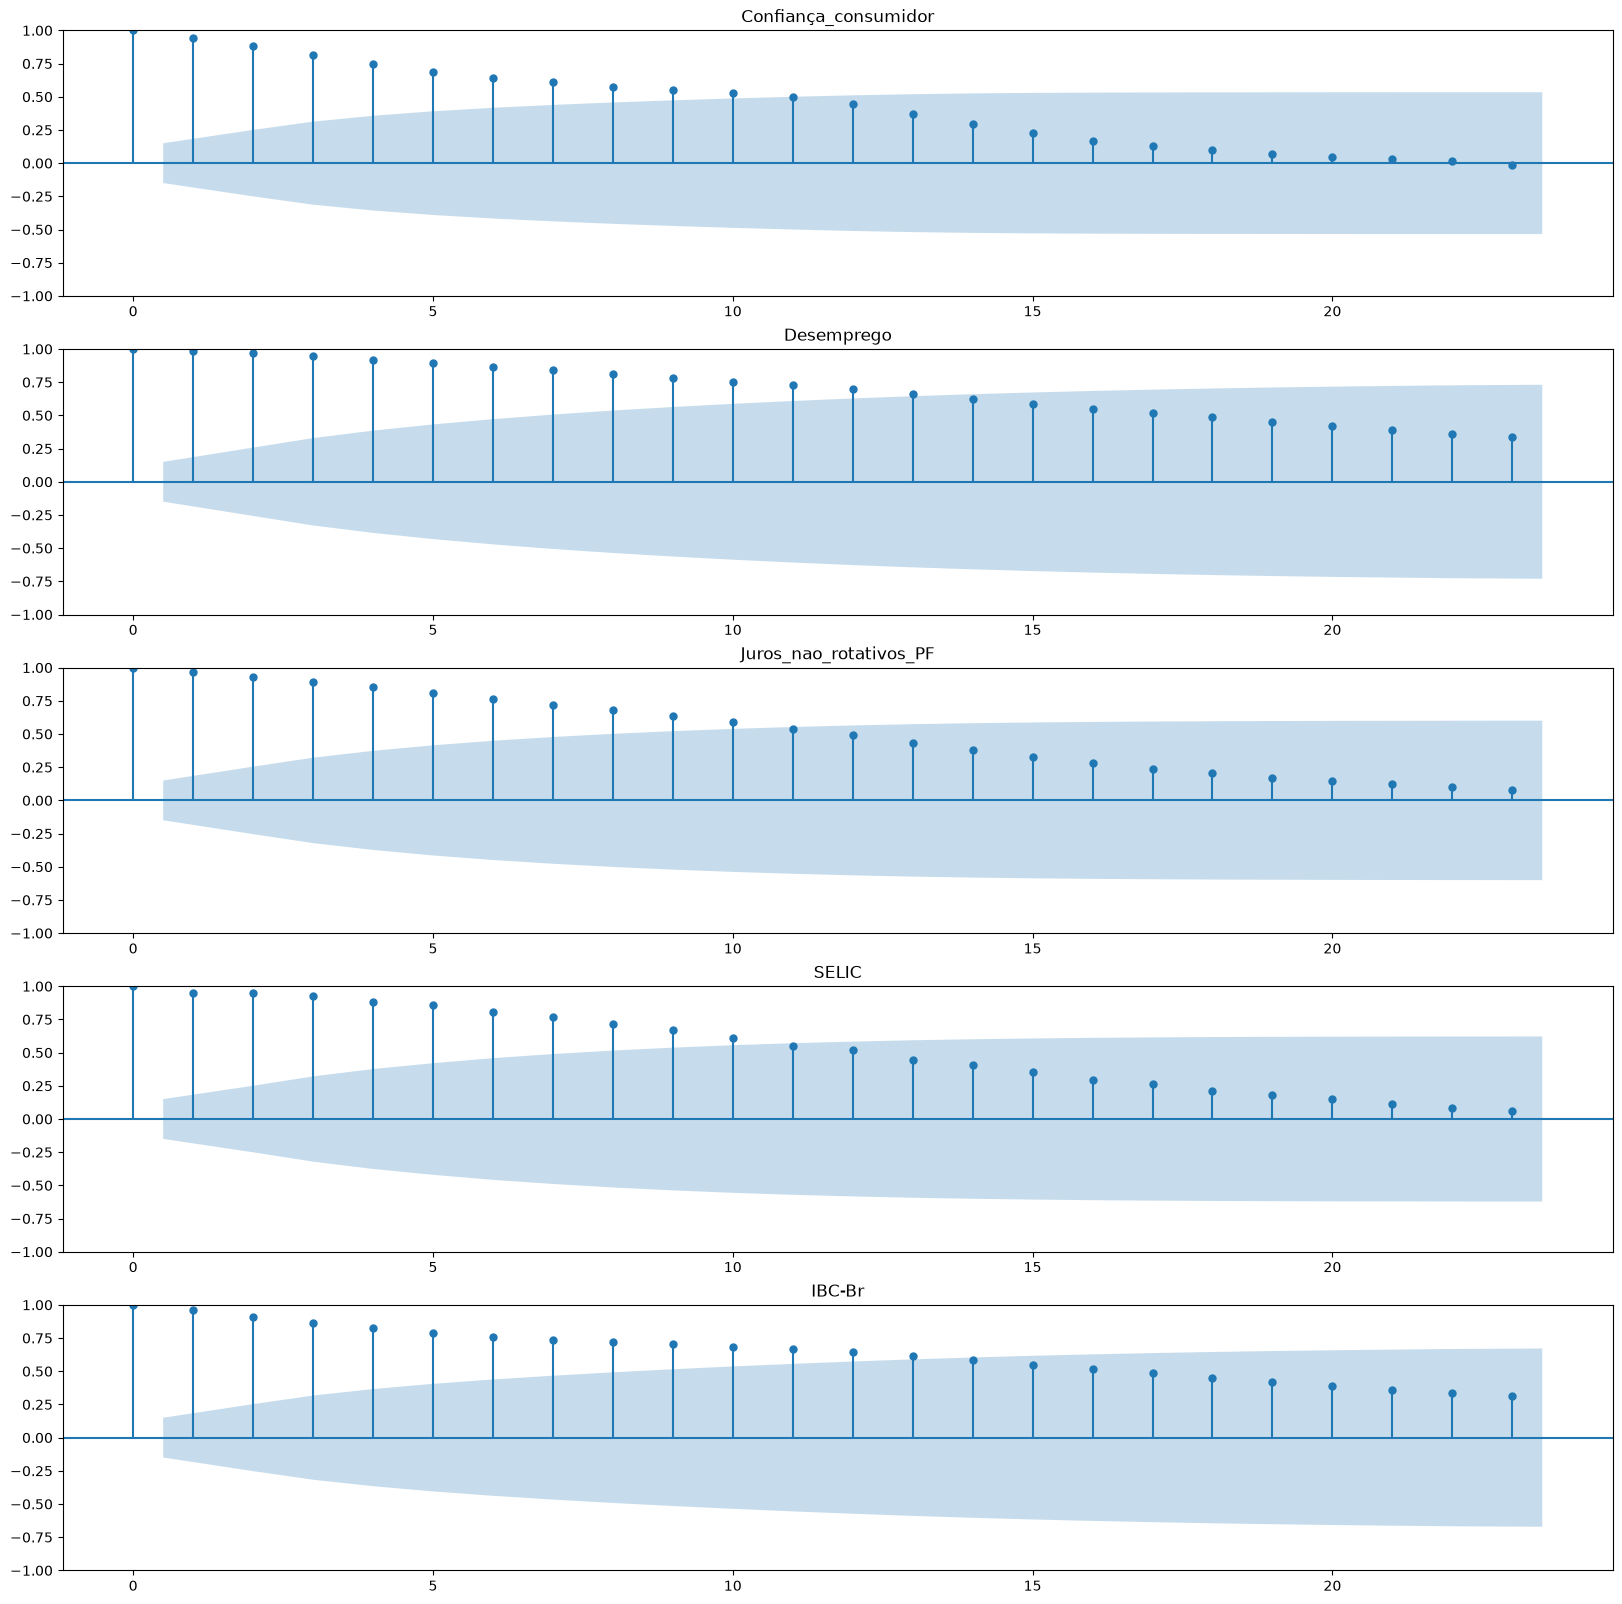

In [26]:
X_acf = X.drop('const', axis=1)
fig, axes = plt.subplots(X_acf.shape[1], 1, figsize=(20,20))
for acf, ax in zip(X_acf.columns, axes):
    sm.graphics.tsa.plot_acf(X_acf[acf], ax=ax)
    ax.set_title(f'{acf}')

In [27]:
# aplicando defasagens para testes 
X_train['Juros_nao_rotativos_PF_lag12'] = X_train['Juros_nao_rotativos_PF'].shift(12)
X_train['SELIC_lag12'] = X_train['SELIC'].shift(12)
X_train['PANDEMIA'] = np.where((X_train.index >= '2020-03-01')&(X_train.index <='2023-04-01'), 1,0)
# X_train = X_train.dropna()


In [28]:
""""
# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem 
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train= X_train.drop(['data', 'Inadimplencia_PF'], axis=1)
X_train.insert(0, 'intercepto',1)
X_train.to_csv(path_modelagem, sep=',', index=False)
"""

'"\n# ja usei esse trecho do codigo, esta comentado para nao interferir na modelagem \nX_train = X_train.reset_index()\npath_modelagem = os.path.join(\'..\', \'modeling\', \'scripts\', \'output\', \'data_modelagem.txt\')\npath_vetor_y = os.path.join(\'..\',\'modeling\', \'scripts\', \'output\', \'vetor_resposta.txt\')\nvetor_resposta = y_train\nvetor_resposta.to_csv(path_vetor_y, sep=\',\', index=False)\nX_train= X_train.drop([\'data\', \'Inadimplencia_PF\'], axis=1)\nX_train.insert(0, \'intercepto\',1)\nX_train.to_csv(path_modelagem, sep=\',\', index=False)\n'

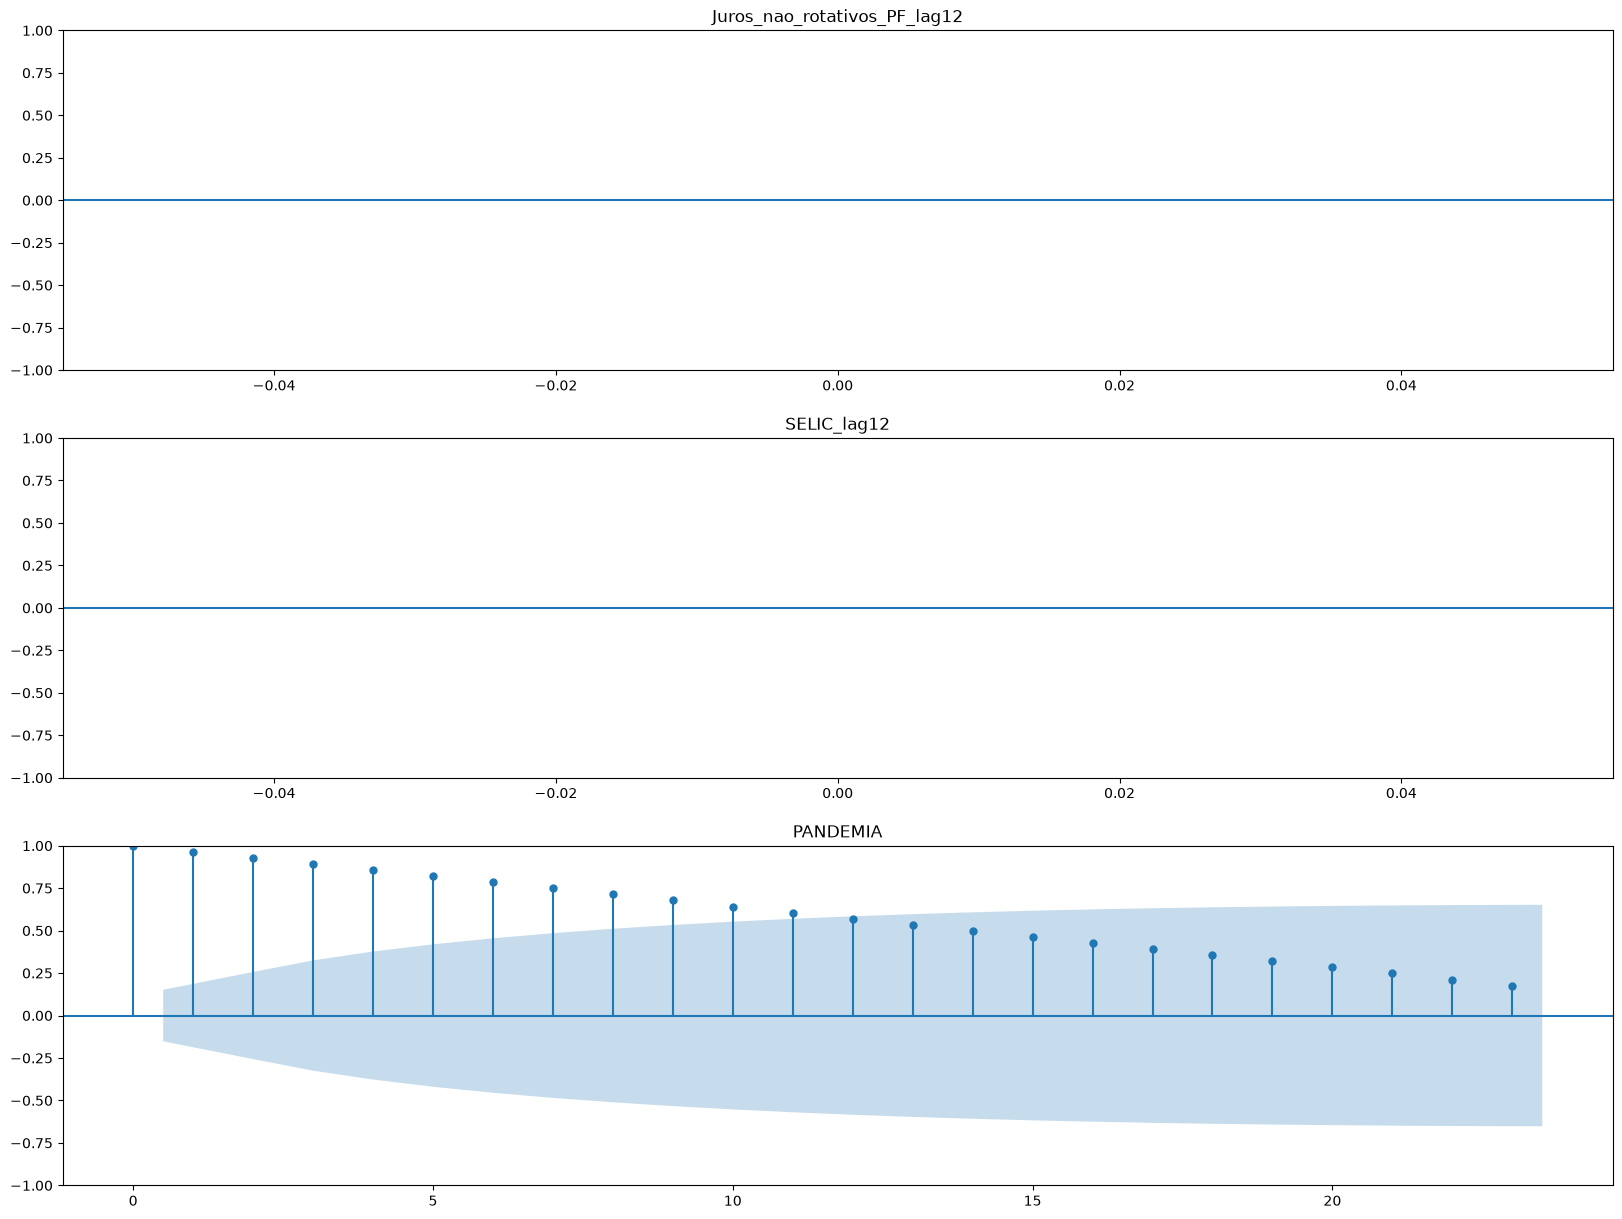

In [29]:
cols_acf = ['Juros_nao_rotativos_PF_lag12', 'SELIC_lag12', 'PANDEMIA']
fig, axes = plt.subplots(len(cols_acf), 1, figsize=(20,15))
for i, ax, in zip(cols_acf, axes):
    sm.graphics.tsa.plot_acf(X_train[i], ax=ax)
    ax.set_title(f'{i}')


nao ouve mudança significativa nas defasagens das variaveis. Mostrando assim que a persistencia é maior do que imaginavamos.

In [30]:
""""
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train= X_train.drop(['data', 'Inadimplencia_PF', 'Juros_nao_rotativos_PF_lag12', 'SELIC_lag12', 'PANDEMIA'], axis=1)
X_train.insert(0, 'intercepto',1)
X_train.to_csv(path_modelagem, sep=',', index=False)
"""

'"\nX_train = X_train.reset_index()\npath_modelagem = os.path.join(\'..\', \'modeling\', \'scripts\', \'output\', \'data_modelagem.txt\')\npath_vetor_y = os.path.join(\'..\',\'modeling\', \'scripts\', \'output\', \'vetor_resposta.txt\')\nvetor_resposta = y_train\nvetor_resposta.to_csv(path_vetor_y, sep=\',\', index=False)\nX_train= X_train.drop([\'data\', \'Inadimplencia_PF\', \'Juros_nao_rotativos_PF_lag12\', \'SELIC_lag12\', \'PANDEMIA\'], axis=1)\nX_train.insert(0, \'intercepto\',1)\nX_train.to_csv(path_modelagem, sep=\',\', index=False)\n'

X-13 ARIMA SEATS

Irei fazer uso do modelo X-13 ARIMA SEATS para tratar sazonalidadas presentes em nossos dados. 

In [31]:
X_train = X_train.drop(['Juros_nao_rotativos_PF_lag12', 'SELIC_lag12', 'PANDEMIA'], axis=1)

In [32]:
# criando atrasos
X_train['SELIC_lag1'] = X_train['SELIC'].shift(1)
X_train['DESEMPREGO_lag3'] = X_train['Desemprego'].shift(3)
X_train['Confiança_consumidor_lag2'] = X_train['Confiança_consumidor'].shift(2)
X_train = X_train.dropna()

coluna Confiança_consumidor OK
coluna Inadimplencia_PF OK
coluna Desemprego OK
coluna Juros_nao_rotativos_PF OK


c:\Users\souza\OneDrive\Área de Trabalho\modelagem inadimplencia\.env\Lib\site-packages\statsmodels\tsa\x13.py:192: X13Warning: WARNING: At least one visually significant trading day peak has been
          found in one or more of the estimated spectra.
  warn(errors, X13Warning)


coluna SELIC OK
coluna IBC-Br OK


c:\Users\souza\OneDrive\Área de Trabalho\modelagem inadimplencia\.env\Lib\site-packages\statsmodels\tsa\x13.py:192: X13Warning: WARNING: At least one visually significant trading day peak has been
          found in one or more of the estimated spectra.
  warn(errors, X13Warning)


coluna SELIC_lag1 OK
coluna DESEMPREGO_lag3 OK
coluna Confiança_consumidor_lag2 OK


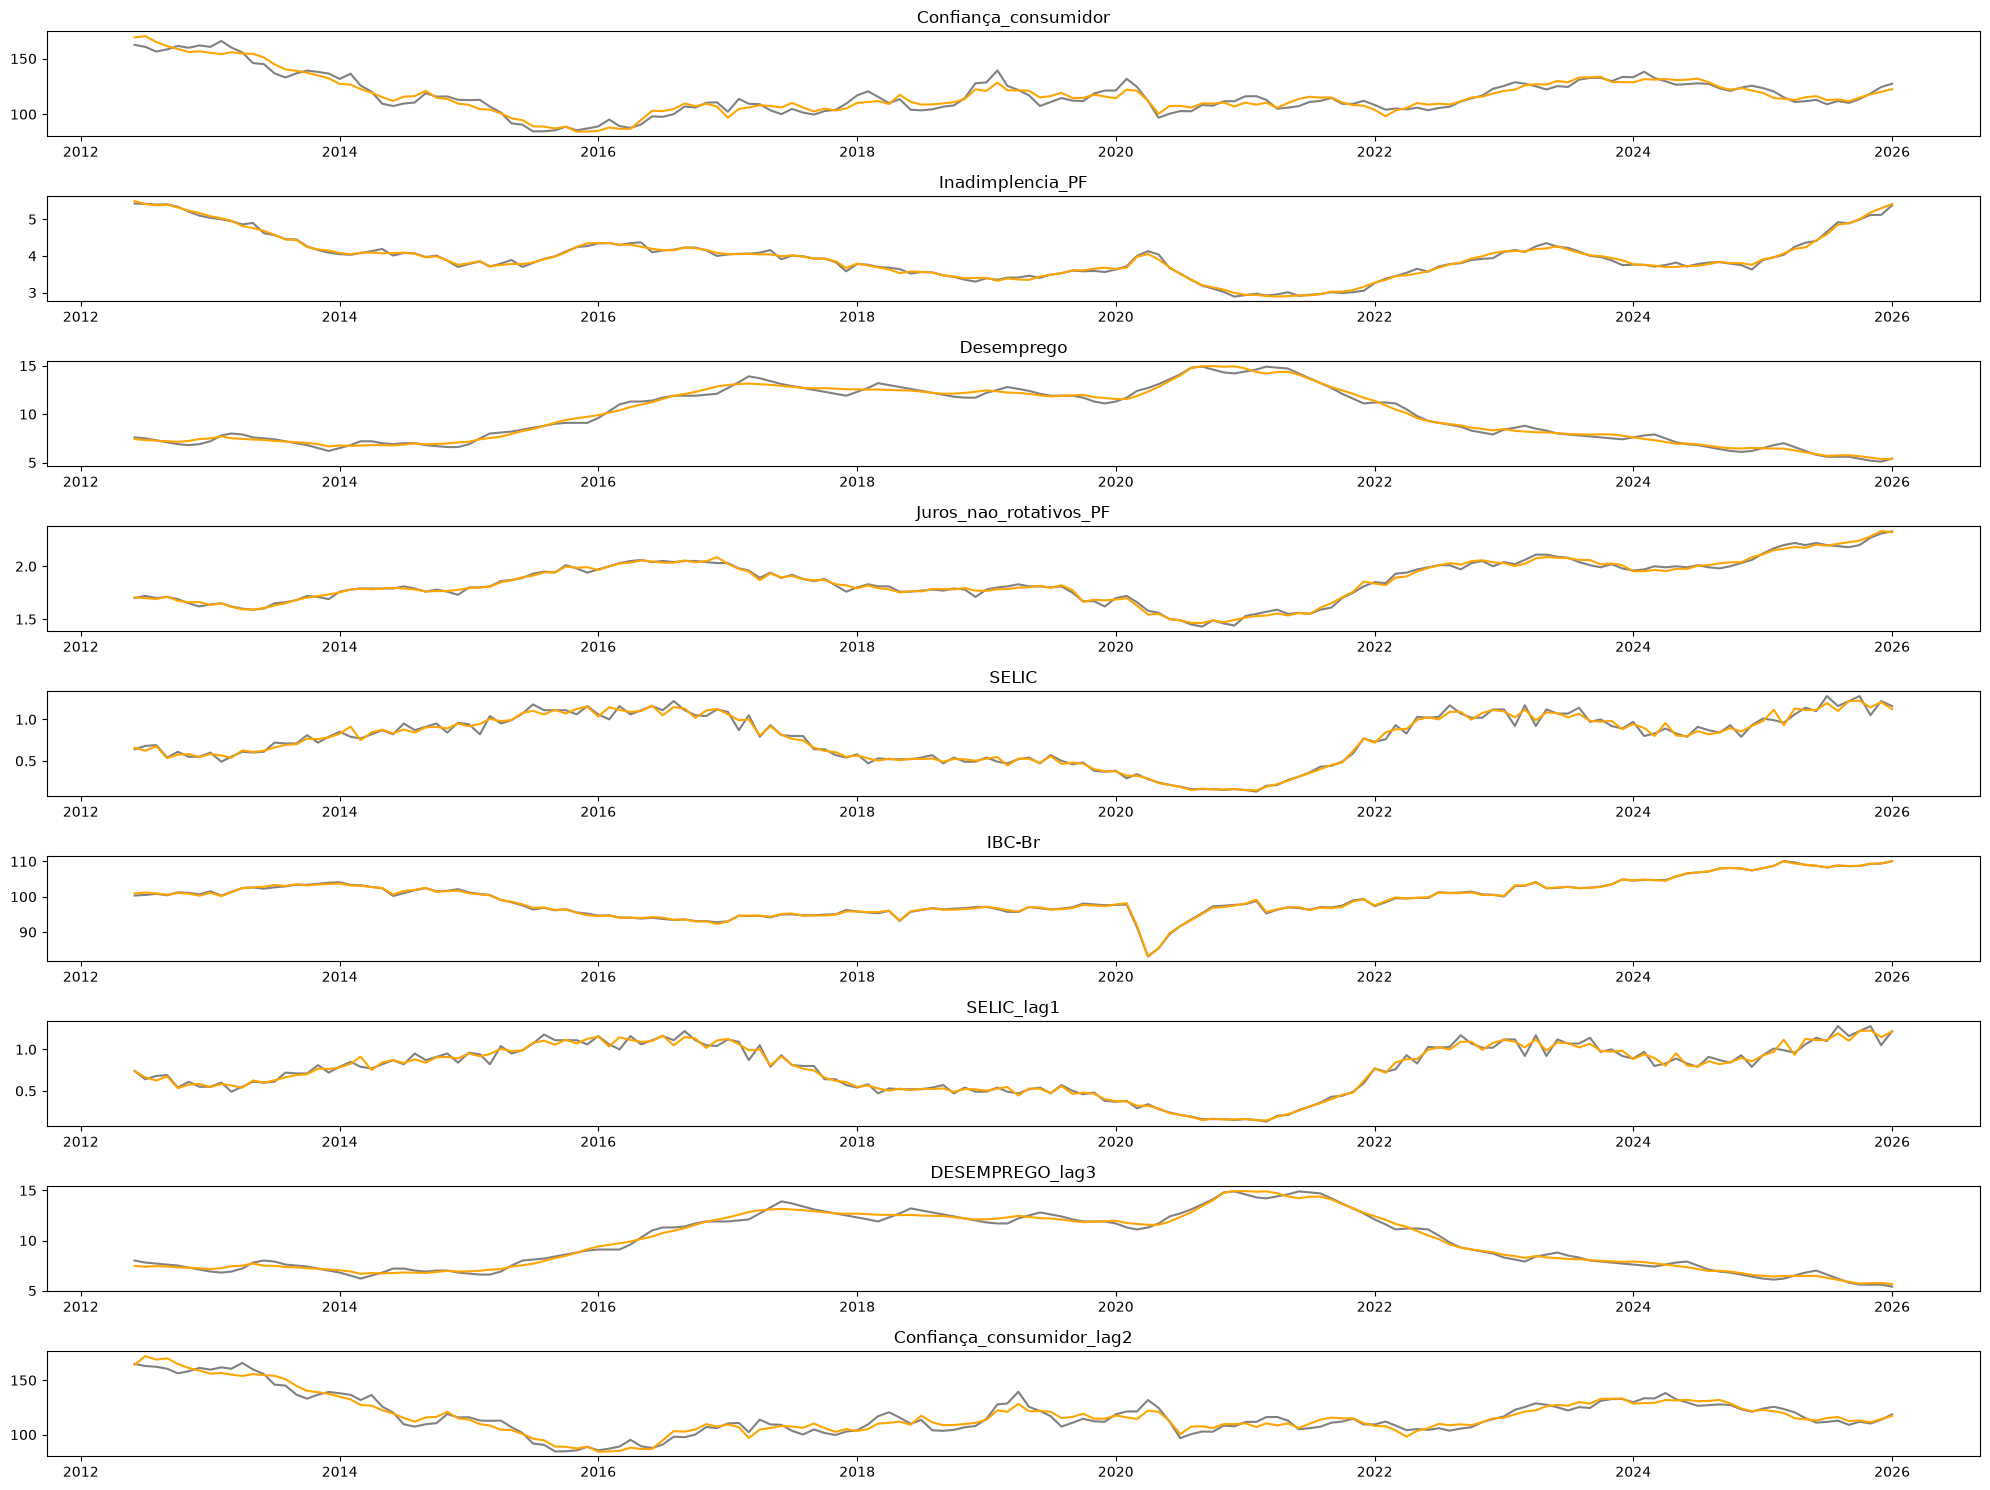

In [33]:
X13_PATH = "C:\\Users\\souza\\Downloads\\x13as_ascii-v1-1-b62 (1)\\x13as"

fig, axes = plt.subplots(X_train.shape[1], 1, figsize=(20,15))
for x13_cols, ax in zip(X_train.columns, axes):
    original = X_train[x13_cols]
    resultado = x13_arima_analysis(X_train[x13_cols], x12path=X13_PATH)
    X_train[x13_cols] = resultado.seasadj
    print(f'coluna {x13_cols} OK')
    ax.plot(original, label='original', color='grey')
    ax.plot(X_train[x13_cols], label='X-13 ARIMA SEATS', color='orange')
    ax.set_title(f'{x13_cols}')
    fig.tight_layout()
    
    

In [34]:
X_train

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,SELIC_lag1,DESEMPREGO_lag3,Confiança_consumidor_lag2
data,,,,,,,,,
2012-06-01,169.039853,5.495944,7.420638,1.705674,0.657502,100.921119,0.738104,7.470353,164.148793
2012-07-01,170.210207,5.418829,7.328159,1.699471,0.622202,101.195497,0.663694,7.382234,172.152927
2012-08-01,164.966691,5.382548,7.266220,1.690367,0.676228,100.937638,0.624217,7.445691,168.934090
2012-09-01,161.199917,5.394196,7.206342,1.712863,0.532675,100.563267,0.673617,7.408797,170.114318
2012-10-01,158.725568,5.322303,7.138936,1.674649,0.574906,101.071279,0.532350,7.328585,164.948285
...,...,...,...,...,...,...,...,...,...
2025-09-01,111.675205,4.892312,5.756249,2.227543,1.220275,108.685048,1.103111,5.883717,112.447269
2025-10-01,114.907001,5.002717,5.654649,2.242139,1.224375,108.781785,1.221311,5.695947,113.014077
2025-11-01,117.987073,5.186354,5.515907,2.282102,1.143217,109.337474,1.226950,5.749297,111.343974


In [35]:
X_train = X_train.reset_index()
path_modelagem = os.path.join('..', 'modeling', 'scripts', 'output', 'data_modelagem.txt')
path_vetor_y = os.path.join('..','modeling', 'scripts', 'output', 'vetor_resposta.txt')
vetor_resposta = y_train
vetor_resposta.to_csv(path_vetor_y, sep=',', index=False)
X_train = X_train.reset_index(drop=True)
X_train= X_train.drop(['data', 'Inadimplencia_PF'], axis=1)
X_train.insert(0, 'intercepto',1)


In [36]:
#X_train = X_train.drop('index', axis=1)
X_train = X_train.dropna()
X_train.to_csv(path_modelagem, sep=',', index=False)

In [37]:
X_train

,intercepto,Confiança_consumidor,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br,SELIC_lag1,DESEMPREGO_lag3,Confiança_consumidor_lag2
0,1,169.039853,7.420638,1.705674,0.657502,100.921119,0.738104,7.470353,164.148793
1,1,170.210207,7.328159,1.699471,0.622202,101.195497,0.663694,7.382234,172.152927
2,1,164.966691,7.266220,1.690367,0.676228,100.937638,0.624217,7.445691,168.934090
3,1,161.199917,7.206342,1.712863,0.532675,100.563267,0.673617,7.408797,170.114318
4,1,158.725568,7.138936,1.674649,0.574906,101.071279,0.532350,7.328585,164.948285
...,...,...,...,...,...,...,...,...,...
159,1,111.675205,5.756249,2.227543,1.220275,108.685048,1.103111,5.883717,112.447269
160,1,114.907001,5.654649,2.242139,1.224375,108.781785,1.221311,5.695947,113.014077
161,1,117.987073,5.515907,2.282102,1.143217,109.337474,1.226950,5.749297,111.343974
162,1,120.093583,5.372134,2.332110,1.208486,109.439322,1.148211,5.750493,114.291521
